<a href="https://colab.research.google.com/github/reitezuz/18NES1-2026/blob/main/week04/perceptron_layer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Motivation: A Layer of perceptrons
- the whole layer is represented by a weight matrix W and a bias vector b
- the training set also consists of two matrices: X (inputs) and D (true outputs)

In [1]:
import numpy as np
N = 4 # number of samples
n = 2 # number of features
m = 5 # number of neurons

# Layer of perceptrons:
W = np.random.uniform(-1,1,(n,m)) # weight matrix (n,m)
b = np.random.uniform(-1,1,(1,m)) # bias vector (1,m)

# Training set:
X = np.random.uniform(-1,1,(N,n)) # input matrix (N,n)
D = np.random.uniform(-1,1,(N,m)) # desired output matrix (N,m)

print("W:", W, sep="\n")
print("b:", b, sep="\n")
print("X:", X, sep="\n")
print("D:", D, sep="\n")


W:
[[-0.06789707  0.85351416 -0.55035598 -0.30413335  0.98949186]
 [-0.70836717 -0.1941292   0.070212    0.05961782  0.91441527]]
b:
[[ 0.48944331 -0.59053059  0.21010656  0.60409936  0.92378899]]
X:
[[-0.76926318  0.13114824]
 [ 0.52037159  0.74848091]
 [ 0.21207833 -0.12334021]
 [-0.51663003  0.72670151]]
D:
[[ 0.44938414 -0.96201623 -0.46050669 -0.75641899 -0.88196443]
 [-0.5106937  -0.41783657  0.17291705  0.48170908  0.05569101]
 [-0.00553436 -0.51915862  0.57922304 -0.9240809  -0.83613783]
 [-0.83867834  0.36195922 -0.0183817   0.42496361 -0.5432168 ]]


- compute the output for a single input pattern

In [2]:
i = 0                     # index of a pattern
x =  X[i,:].reshape(1,-1) # input pattern (1,n)

# Internal potential:
xi = x @ W + b            # (1,n) @ (n,m) => (1, m)

# Output (for tanh and sigmoid):
y = np.tanh(xi)            # (1, m) ... tanh
y1 = 1 / (1 + np.exp(-xi)) # (1, m) ... sigmoid

print("xi:", xi, sep="\n")
print("y (tanh):", y, sep="\n")
print("y1 (sigmoid):", y1, sep="\n")

xi:
[[ 0.44877292 -1.27256732  0.64268334  0.84587672  0.28253329]]
y (tanh):
[[ 0.42088982 -0.85449195  0.56672384  0.68890923  0.27524807]]
y1 (sigmoid):
[[0.61034744 0.21881809 0.65535978 0.69970148 0.57016718]]


- the model is able to compute the potential and output for the whole dataset at once:

In [3]:
# Internal Potential:
Xi = X @ W + b             # (N,n) @ (n,m) => (N, m)

# Output (for tanh and sigmoid):
Y = np.tanh(Xi)            # (N, m) ... tanh
Y1 = 1 / (1 + np.exp(-Xi)) # (N, m) ... sigmoid

# At once:
Y = np.tanh(X @ W + b)     # (N, m)
Y1 = 1 / (1 + np.exp(-(X @ W + b))) # (N, m)

print("Xi:", Xi, sep="\n")
print("Y (tanh):", Y, sep="\n")
print("Y1 (sigmoid):", Y1, sep="\n")


Xi:
[[ 0.44877292 -1.27256732  0.64268334  0.84587672  0.28253329]
 [-0.07608769 -0.29168807 -0.02373071  0.4904598   2.12311482]
 [ 0.56241397 -0.3855748   0.08472802  0.53224599  1.0208546 ]
 [ 0.00974949 -1.17255563  0.54546016  0.80454814  1.07709473]]
Y (tanh):
[[ 0.42088982 -0.85449195  0.56672384  0.68890923  0.27524807]
 [-0.0759412  -0.28368777 -0.02372626  0.45458129  0.971768  ]
 [ 0.5097663  -0.36753905  0.08452586  0.48709606  0.77021439]
 [ 0.00974918 -0.82508972  0.49710997  0.66657176  0.79211924]]
Y1 (sigmoid):
[[0.61034744 0.21881809 0.65535978 0.69970148 0.57016718]
 [0.48098725 0.42759065 0.4940676  0.62021474 0.8931296 ]
 [0.6370109  0.40478303 0.52116934 0.6300068  0.73513903]
 [0.50243735 0.23639335 0.63308167 0.69094653 0.7459438 ]]


- one step of the iterative algorithm:

In [4]:
i = 0                     # index of current pattern
x =  X[i,:].reshape(1,-1) # input pattern (1,n)
d = D[i,:].reshape(1,-1)  # real output (1,m)

# Compute the predicted output (for all perceptrons at once)
y = np.tanh(x @ W + b)    #  (1,n) @ (n, m) -> (1, m)

# Compute the weight and bias changes  (for all perceptrons at once)
tanh_derivative = 1 - y ** 2                   # (1,m)
sigmoid_derivative = y * (1 - y)               # (1,m)
W_change = x.T @ (tanh_derivative * (d - y))   # (n,1) @ (1,m) -> (n,m)
b_change = tanh_derivative * (d - y)           # (1,m) * (1,m) -> (1,m)

# Change the weights and biases:
W += W_change
b += b_change

print(f"x: {x.shape}\n{x}")
print(f"d: {d.shape}\n{d}")
print(f"y: {y.shape}\n{y}")
print(f"W_change: {W_change.shape}\n{W_change}")
print(f"b_change: {b_change.shape}\n{b_change}")


x: (1, 2)
[[-0.76926318  0.13114824]]
d: (1, 5)
[[ 0.44938414 -0.96201623 -0.46050669 -0.75641899 -0.88196443]]
y: (1, 5)
[[ 0.42088982 -0.85449195  0.56672384  0.68890923  0.27524807]]
W_change: (2, 5)
[[-0.01803661  0.02231996  0.53641401  0.5841641   0.82275801]
 [ 0.00307498 -0.00380523 -0.09145083 -0.09959153 -0.14026834]]
b_change: (1, 5)
[[ 0.0234466  -0.02901473 -0.69730883 -0.75938133 -1.06954035]]


- one step of the batch algorithm (even more efficient):

In [5]:
# Compute the predicted output (for all perceptrons and input patterns at once)
Y = np.tanh(X @ W + b)    #  (N,m)

# Compute the weight and bias changes  (for all perceptrons and input patterns at once)
tanh_derivative = 1 - Y ** 2                   # (N,m)
sigmoid_derivative = Y * (1 - Y)               # (N,m)
W_change = X.T @ (tanh_derivative * (D - Y))   # (n,N) @ (N,m) -> (n,m)
b_change = (tanh_derivative * (D - Y)).sum(axis=0).reshape(1, -1)  # (N,m) * (N,m) ->[sum by rows]-> (1,m)

# Change the weights and biases:
W += W_change
b += b_change

print(f"x: {x.shape}\n{x}")
print(f"d: {d.shape}\n{d}")
print(f"y: {y.shape}\n{y}")
print(f"W_change: {W_change.shape}\n{W_change}")
print(f"b_change: {b_change.shape}\n{b_change}")

x: (1, 2)
[[-0.76926318  0.13114824]]
d: (1, 5)
[[ 0.44938414 -0.96201623 -0.46050669 -0.75641899 -0.88196443]]
y: (1, 5)
[[ 0.42088982 -0.85449195  0.56672384  0.68890923  0.27524807]]
W_change: (2, 5)
[[ 0.14139627 -0.24424803  0.26425871  0.01671549 -0.27537129]
 [-0.92991252  0.19109229  0.52478159  0.93124217 -0.05747639]]
b_change: (1, 5)
[[-1.71681025  0.11625861  1.65713849  0.01552698 -1.19283484]]


# Perceptron Layer with continuous activation function and the gradient descent training algorithm (minimizing the SSE error function)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import time

class PerceptronLayer:
    def __init__(self, input_dim, num_neurons, activation_function='linear', init_method='zero'):
        # Dimensions:
        # inputs: (number of samples, number of features) (N, n)
        # weights: (number of features, number of neurons) (n, m)
        # biases: (1, number of neurons) (1, m)

        # weight initialization
        if init_method == 'random':
            self.weights = np.random.uniform(-1, 1, (input_dim, num_neurons)) / 10  # (number of features, number of neurons)
            self.biases = np.random.uniform(-1, 1, (1, num_neurons)) / 10  # (1, number of neurons)
        elif init_method == 'widrow-hoff':
            self.weights = np.random.randn(input_dim, num_neurons) * (2 / np.sqrt(input_dim))  # (number of features, number of neurons)
            self.biases = np.random.randn(1, num_neurons) * (2 / np.sqrt(input_dim))  # (1, number of neurons)
        else: # zeros
            self.weights = np.zeros((input_dim, num_neurons))  # (number of features, number of neurons)
            self.biases = np.zeros((1, num_neurons))  # (1, number of neurons)

        self.activation_function = activation_function
        self.epochs = -1

    def set_weights(self, weights, biases):
        self.weights = np.array(weights, dtype=float).reshape(self.weights.shape)  # (number of features, number of neurons)
        self.biases = np.array(biases, dtype=float).reshape(1, -1)  # (1, number of neurons)

    def __str__(self):
        return f"PerceptronLayer(weights={self.weights.shape}, biases={self.biases.shape})"

    def error(self, true_outputs, predicted_outputs, loss_function='CCE'):
        if loss_function == 'SSE':
            return np.mean((true_outputs - predicted_outputs) ** 2)
        if loss_function == 'BCE':
            predicted_outputs = np.clip(predicted_outputs, 1e-12, 1 - 1e-12)
            return -np.mean(true_outputs * np.log(predicted_outputs) + (1 - true_outputs) * np.log(1 - predicted_outputs))
        elif loss_function == 'CCE':
            predicted_outputs = np.clip(predicted_outputs, 1e-12, 1 - 1e-12)
            return -np.mean(np.sum(true_outputs * np.log(predicted_outputs), axis=1))

    def activation(self, x):
        if self.activation_function == 'linear':
            return x
        elif self.activation_function == 'tanh':
            return np.tanh(x)
        elif self.activation_function == 'sigmoid':
            return 1 / (1 + np.exp(-x))
        elif self.activation_function == 'softmax':
            exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
            return exp_x / np.sum(exp_x, axis=1, keepdims=True)
        else:
            raise ValueError("Unknown activation function")

    def forward(self, inputs):
        # Dimensions:
        # inputs: (number of samples, number of features)
        # weights: (number of features, number of neurons)
        # biases: (1, number of neurons)
        # output: (number of samples, number of neurons)
        potential = inputs @ self.weights + self.biases  # (number of samples, number of neurons)
        return self.activation(potential)  # (number of samples, number of neurons)

    def gradient_descent_iterative(self, training_inputs, true_outputs, learning_rate=1, epochs=100, adaptive_learning_rate=True, min_error=0, max_validation_steps=None, validation_set=None, print_progress=False, error_name='SSE'):
        learning_rate_0 = learning_rate
        training_errors = []
        validation_errors = []

        if print_progress:
            print("Gradient Descent Iterative:")

        if validation_set is not None:
            validation_inputs, validation_true_outputs = validation_set
            validation_steps = 0
            previous_validation_error = self.error(validation_true_outputs, self.forward(validation_inputs))

        for epoch in range(epochs):
            shuffled_indices = np.random.permutation(training_inputs.shape[0])
            training_inputs = training_inputs[shuffled_indices, :]
            true_outputs = true_outputs[shuffled_indices, :]

            for inputs, true_output in zip(training_inputs, true_outputs):
                inputs = inputs.reshape(1, -1)  # (1, number of features)
                true_output = true_output.reshape(1, -1)  # (1, number of neurons)
                prediction = self.forward(inputs)  # (1, number of neurons)
                error = true_output - prediction  # (1, number of neurons)

                if error_name == 'SSE':
                    if self.activation_function == 'linear':
                        grad = error
                    elif self.activation_function == 'tanh':
                        grad = error * (1 - prediction ** 2)
                    elif self.activation_function == 'sigmoid':
                        grad = error * prediction * (1 - prediction)
                    else:
                        raise ValueError("Unknown activation")
                elif error_name == 'BCE':
                    # sigmoid!
                    grad = error

                elif error_name == 'CCE':
                    # softmax!
                    grad = error
                else:
                    raise ValueError("Unknown error function")

                self.weights += learning_rate * inputs.T @ grad  # (number of features, number of neurons)
                self.biases += learning_rate * grad  # (1, number of neurons)

            if adaptive_learning_rate:
                learning_rate = learning_rate_0 / ((epoch//100 + 1) ** 0.5)

            if validation_set:
                validation_error = self.error(validation_true_outputs, self.forward(validation_inputs), error_name)
                if validation_error < previous_validation_error:
                    validation_steps = 0
                else:
                    validation_steps += 1
                previous_validation_error = validation_error
                validation_errors.append(validation_error)

            training_error = self.error(true_outputs, self.forward(training_inputs), error_name)

            if print_progress and epoch % 100 == 0:
                if validation_set:
                    print(f"Epoch: {epoch}, Training error ({error_name}):{training_error:0.4f}, Validation error: {validation_error} Average of Weights: {np.mean(self.weights)}  Learning rate: {learning_rate:.4f}")
                else:
                    print(f"Epoch: {epoch}, Training error ({error_name}):{training_error:0.4f} Average of Weights: {np.mean(self.weights)}  Learning rate: {learning_rate:.4f}")
            # Stop conditions:

            training_errors.append(training_error)
            if (training_error <= min_error):
                msg = "Minimum error reached."
                break
            elif (max_validation_steps and (validation_steps > max_validation_steps)):
                msg = "Maximum validation steps reached."
                break
            else:
                msg = "Maximum epochs reached."
        if print_progress:
            print(f"The training ended after {epoch+1} epochs.", msg)

        self.epochs = epoch + 1
        return training_errors, validation_errors

    def gradient_descent_batch(self, training_inputs, true_outputs, learning_rate=1, epochs=100, adaptive_learning_rate=True, min_error=0, max_validation_steps=None, validation_set=None, print_progress=False, error_name='SSE'):
        learning_rate_0 = learning_rate
        training_errors = []
        validation_errors = []

        if print_progress:
            print("Gradient Descent Batch:")

        if validation_set is not None:
            validation_inputs, validation_true_outputs = validation_set
            validation_steps = 0
            previous_validation_error = self.error(validation_true_outputs, self.forward(validation_inputs))

        for epoch in range(epochs):
            prediction = self.forward(training_inputs)  # (number of samples, number of neurons)
            error = true_outputs - prediction  # (number of samples, number of neurons)


            if error_name == 'SSE':
                if self.activation_function == 'linear':
                    grad = error
                elif self.activation_function == 'tanh':
                    grad = error * (1 - prediction ** 2)
                elif self.activation_function == 'sigmoid':
                    grad = error * prediction * (1 - prediction)
                else:
                    raise ValueError("Unknown activation")
            elif error_name == 'BCE':
                grad = error
            elif error_name == 'CCE':
                grad = error

            weight_gradient = (training_inputs.T @ grad) / training_inputs.shape[0]  # (number of features, number of neurons)
            bias_gradient = np.mean(grad, axis=0, keepdims=True)  # (1, number of neurons)

            self.weights += learning_rate * weight_gradient  # (number of features, number of neurons)
            self.biases += learning_rate * bias_gradient  # (1, number of neurons)

            if adaptive_learning_rate:
                learning_rate = learning_rate_0 / ((epoch + 1) ** 0.5)

            if validation_set:
                validation_error = self.error(validation_true_outputs, self.forward(validation_inputs), error_name)
                validation_errors.append(validation_error)
                if validation_error < previous_validation_error:
                    validation_steps = 0
                else:
                    validation_steps += 1
                previous_validation_error = validation_error

            training_error = self.error(true_outputs, self.forward(training_inputs), error_name)
            training_errors.append(training_error)
            if print_progress and epoch % 100 == 0:
                if validation_set:
                    print(f"Epoch: {epoch}, Training error ({error_name}):{training_error:0.4f}, Validation error: {validation_error} Average of Weights: {np.mean(self.weights)}  Learning rate: {learning_rate:.4f}")
                else:
                    print(f"Epoch: {epoch}, Training error ({error_name}):{training_error:0.4f}, Validation error: {validation_error}  Average of Weights: {np.mean(self.weights)}  Learning rate: {learning_rate:.4f}")

            # Stop conditions:
            if (training_error <= min_error):
                msg = "Minimum error reached."
                break
            elif (max_validation_steps and validation_steps > max_validation_steps):
                msg = "Maximum validation steps reached."
                break
            else:
                msg = "Maximum epochs reached."
        if print_progress:
            print(f"The training ended after {epoch+1} epochs.", msg)

        self.epochs = epoch + 1
        return training_errors, validation_errors


def sign(x):
    return np.where(x > 0, 1, np.where(x < 0, -1, 0))

def ensure_same_dimensions(true_outputs, predicted_outputs):
    true_outputs = np.asarray(true_outputs)           # ensure array
    predicted_outputs = np.asarray(predicted_outputs)
    true_outputs = true_outputs.reshape(1, -1) if true_outputs.ndim == 1 else true_outputs
    predicted_outputs = predicted_outputs.reshape(1, -1) if predicted_outputs.ndim == 1 else predicted_outputs

    if true_outputs.shape != predicted_outputs.shape:
        raise ValueError(f"Shape mismatch: {true_outputs.shape} vs {predicted_outputs.shape}")
    return true_outputs, predicted_outputs

def perceptron_error(true_outputs, predicted_outputs):
    true_outputs, predicted_outputs = ensure_same_dimensions(true_outputs, predicted_outputs)
    return np.sum(true_outputs != np.round(predicted_outputs))

def SSE_error(true_outputs, predicted_outputs):
    true_outputs, predicted_outputs = ensure_same_dimensions(true_outputs, predicted_outputs)
    return np.sum((true_outputs - predicted_outputs) ** 2)

def SAE_error(true_outputs, predicted_outputs):
    true_outputs, predicted_outputs = ensure_same_dimensions(true_outputs, predicted_outputs)
    return np.sum(np.abs(true_outputs - predicted_outputs))

def MAE_error(true_outputs, predicted_outputs):
    true_outputs, predicted_outputs = ensure_same_dimensions(true_outputs, predicted_outputs)
    return np.mean(np.abs(true_outputs - predicted_outputs))

def MSE_error(true_outputs, predicted_outputs):
    true_outputs, predicted_outputs = ensure_same_dimensions(true_outputs, predicted_outputs)
    return np.mean((true_outputs - predicted_outputs) ** 2)

def RMSE_error(true_outputs, predicted_outputs):
    true_outputs, predicted_outputs = ensure_same_dimensions(true_outputs, predicted_outputs)
    return np.sqrt(np.mean((true_outputs - predicted_outputs) ** 2))

import numpy as np


def accuracy(true_outputs, predicted_outputs, activation_function=None):
    true_outputs, predicted_outputs = ensure_same_dimensions(true_outputs, predicted_outputs)


    if true_outputs.shape[1] == 1:
        if activation_function == 'sigmoid':
            predicted_labels = (predicted_outputs >= 0.5).astype(int)
        elif activation_function == 'tanh':
            predicted_labels = (predicted_outputs >= 0.0).astype(int)
        else:
            predicted_labels = (predicted_outputs >= 0.0).astype(int)

        return np.mean(predicted_labels == true_outputs)

    else:
        predicted_labels = np.argmax(predicted_outputs, axis=1)
        true_labels = np.argmax(true_outputs, axis=1)

        return np.mean(predicted_labels == true_labels)

def misclassified_indices(true_outputs, predicted_outputs):
    """
    Identifies indices of misclassified samples in classification with real-valued outputs.

    Parameters:
    - true_outputs: ndarray of shape (N, m), one-hot encoded true labels (for multi-class)
    - predicted_outputs: ndarray of shape (N, m), real-valued predictions (probabilities or scores)

    Returns:
    - misclassified_indices: ndarray of shape (K,), indices of misclassified samples
    """
    true_outputs, predicted_outputs = ensure_same_dimensions(true_outputs, predicted_outputs)

    if predicted_outputs.shape[1] == 1:
        predicted_labels = (predicted_outputs >= 0.5).astype(int)  # sigmoid
    else:  # Multi-class classification (m > 1)
        predicted_labels = np.argmax(predicted_outputs, axis=1)  # Get predicted class index
        true_outputs = np.argmax(true_outputs, axis=1)  # Convert one-hot encoding to class indices

    misclassified = np.where(predicted_labels != true_outputs)[0]  # Get indices of incorrect predictions

    return misclassified

def binary_cross_entropy_sigmoid(y_true, y_pred, epsilon=1e-12):
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean( y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred) )

def categorical_cross_entropy(y_true, probs, epsilon=1e-12):
    probs = np.clip(probs, epsilon, 1 - epsilon)
    return -np.mean(np.sum(y_true * np.log(probs), axis=1))



In [7]:
# test of dimensions
p = PerceptronLayer(n,m,activation_function='tanh',init_method='random')
print(p)
X = np.random.uniform(-1,1,(N,n))
D = np.random.uniform(-1,1,(N,m))
Y = p.forward(X)
print(Y, Y.shape, sep="\n")

x = np.random.uniform(-1,1,(1,n))
d = np.random.uniform(-1,1,(1,m))
y = p.forward(x)
print(y, y.shape, sep="\n")

PerceptronLayer(weights=(2, 5), biases=(1, 5))
[[ 0.02016291 -0.10493041 -0.06810791  0.00048528  0.02585371]
 [-0.01585157 -0.03758159 -0.04805006  0.05512326  0.04604607]
 [-0.00966349 -0.06477948 -0.0634067   0.02087331  0.03417246]
 [ 0.02401331 -0.04566696 -0.01927495  0.10079682  0.05962813]]
(4, 5)
[[ 0.06780022 -0.10648017 -0.02749921  0.06836038  0.04651183]]
(1, 5)


### Axiliary functions:


In [8]:
def run_example_multiple_times_classification(experiment_results, training_data, testing_data, testing_data2, validation_data, activation, epochs, init_method, learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, error_name, max_validation_steps=10, num_runs=10):
    inputs, true_outputs = training_data
    if testing_data is None:
        testing_data = training_data
    if testing_data2 is None:
        testing_dat2 = testing_data
    max_validation_steps = None if validation_data is None else max_validation_steps
    test_inputs, test_true_outputs = testing_data
    test_inputs2, test_true_outputs2 = testing_data2
    times = []
    mse_errors = []
    accuracy_errors = []
    mse_test_errors = []
    accuracy_test_errors = []
    mse_test_errors2 = []
    accuracy_test_errors2 = []
    epoch_counts = []

    for _ in range(num_runs):

        start_time = time.time()
        neuron = PerceptronLayer(inputs.shape[1], true_outputs.shape[1], activation, init_method)

        if variant == 'iterative':
            [training_errors, validation_errors] = neuron.gradient_descent_iterative(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress, error_name)
        else:
            [training_errors, validation_errors] =     neuron.gradient_descent_batch(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress, error_name)

        end_time = time.time()
        elapsed_time = end_time - start_time

        real_outputs = neuron.forward(inputs)
        mse = MSE_error(true_outputs, real_outputs)
        acc = accuracy(true_outputs, real_outputs)

        real_outputs = neuron.forward(test_inputs)
        mse_test = MSE_error(test_true_outputs, real_outputs)
        acc_test = accuracy(test_true_outputs, real_outputs)

        recalled_outputs = neuron.forward(test_inputs2)
        mse_test2 = MSE_error(test_true_outputs2, real_outputs)
        acc_test2 = accuracy(test_true_outputs2, real_outputs)

        times.append(elapsed_time)
        mse_errors.append(mse)
        accuracy_errors.append(acc)
        mse_test_errors.append(mse_test)
        accuracy_test_errors.append(acc_test)
        mse_test_errors2.append(mse_test2)
        accuracy_test_errors2.append(acc_test2)
        epoch_counts.append(neuron.epochs)

    avg_time = np.mean(times)
    avg_mse = np.mean(mse_errors)
    avg_mse_test = np.mean(mse_test_errors)
    avg_acc = np.mean(accuracy_errors)
    acc_sum = np.sum(np.array(accuracy_errors) > 0.98)
    avg_acc_test = np.mean(accuracy_test_errors)
    avg_mse_test2 = np.mean(mse_test_errors2)
    avg_acc_test2 = np.mean(accuracy_test_errors2)
    avg_epochs = np.mean(epoch_counts)

    results = {
        'Epochs': avg_epochs,
        'MSE': avg_mse,
        'Accuracy': avg_acc,
        'Test MSE': avg_mse_test,
        'Test Accuracy': avg_acc_test,
        'Sum Accuracy': acc_sum,
        'Test MSE2': avg_mse_test2,
        'Test Accuracy2': avg_acc_test2,
        'Time': avg_time,
        'Variant': variant,
        'Learning Rate': learning_rate,
        'Adaptive Learning Rate': adaptive_learning_rate,
        'Activation Function': activation,
        'Init Method': init_method,
        'Max Epochs': epochs,
        'Data Description': data_description,

    } #experiment_results_r = pd.DataFrame(columns=['MSE', 'SSE', 'Test MSE' 'Test MAE', 'Epochs', 'Time', 'Variant', 'Learning Rate', 'Max Epochs', 'Weights', 'Bias', 'Data Description'])

    experiment_results.loc[len(experiment_results)] = results

    if num_runs == 1:
         plot_error_progress(training_errors, validation_errors)
    return neuron

def run_example_multiple_times_regression(experiment_results, training_data, testing_data, validation_data, activation, epochs, init_method, learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps=10, num_runs=10):
    inputs, true_outputs = training_data
    if testing_data is None:
        testing_data = training_data
    max_validation_steps = None if validation_data is None else max_validation_steps
    test_inputs, test_true_outputs = testing_data
    times = []
    mse_errors = []
    mae_errors = []
    mse_test_errors = []
    mae_test_errors = []
    epoch_counts = []

    for _ in range(num_runs):

        start_time = time.time()
        neuron = PerceptronLayer(inputs.shape[1], true_outputs.shape[1], activation, init_method)

        if variant == 'iterative':
            [training_errors, validation_errors] = neuron.gradient_descent_iterative(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress)
        else:
            [training_errors, validation_errors] = neuron.gradient_descent_batch(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, print_progress, print_progress=print_progress)

        end_time = time.time()
        elapsed_time = end_time - start_time

        real_outputs = neuron.forward(inputs)
        mse = MSE_error(true_outputs, real_outputs)
        mae = MAE_error(true_outputs, real_outputs)

        real_outputs = neuron.forward(test_inputs)
        mse_test = MSE_error(test_true_outputs, real_outputs)
        mae_test = MAE_error(test_true_outputs, real_outputs)

        times.append(elapsed_time)
        mse_errors.append(mse)
        mae_errors.append(mae)
        mse_test_errors.append(mse_test)
        mae_test_errors.append(mae_test)
        epoch_counts.append(neuron.epochs)

    avg_time = np.mean(times)
    avg_mse = np.mean(mse_errors)
    avg_mae = np.mean(mae_errors)
    avg_test_mse = np.mean(mse_test_errors)
    avg_test_mae = np.mean(mae_test_errors)
    avg_epochs = np.mean(epoch_counts)

    results = {
        'Epochs': avg_epochs,
        'MSE': avg_mse,
        'MAE': avg_mae,
        'Test MSE': avg_test_mse,
        'Test MAE': avg_test_mae,
        'Time': avg_time,
        'Variant': variant,
        'Learning Rate': learning_rate,
        'Max Epochs': epochs,
        'Weights': neuron.weights,  # Note: Weights and bias are from the last run.
        'Bias': neuron.bias,
        'Data Description': data_description
    } #experiment_results_r = pd.DataFrame(columns=['MSE', 'SSE', 'Test MSE' 'Test MAE', 'Epochs', 'Time', 'Variant', 'Learning Rate', 'Max Epochs', 'Weights', 'Bias', 'Data Description'])

    experiment_results.loc[len(experiment_results)] = results

    if num_runs == 1:
         plot_error_progress(training_errors, validation_errors)
    return neuron

def plot_error_progress(train_errors, validation_errors):
    fig = plt.figure(figsize=(4, 3))
    if validation_errors:
        plt.plot(validation_errors, label='Validation Error')
    plt.plot(train_errors, label='Train Error')
    plt.xlabel('Epoch')
    plt.ylabel('Error')
    plt.title('Validation and Train Error Progress')
    plt.legend()
    plt.grid(True)
    plt.show()


def one_hot_encode(d, num_classes=None):
    """
    Converts a vector of class labels (N,1) into a one-hot encoded matrix (N, m) using NumPy.

    Parameters:
    - d: ndarray of shape (N, 1) or (N,), containing class indices (0 to m-1)
    - num_classes: int, total number of classes (if None, inferred from max value in d)

    Returns:
    - one_hot: ndarray of shape (N, m), where each row is a one-hot vector
    """
    d = np.asarray(d).reshape(-1)  # Convert (N,1) to (N,) if necessary

    if num_classes is None:
        num_classes = np.max(d) # Infer number of classes if not provided

    return np.eye(num_classes)[d-1] # Efficient one-hot encoding




# Example 1: Gallblader attack
- now, we train three tasks at once:
    1. Gallblader attack
    2. Egg Salad
    3. Majority Circuit

In [9]:
def example_gallblader_attack():
    # Egg Salad, Pork Belly, Medicines -> Gallbladder Attack, Egg Salad, Majority
    inputs = np.array([
        [+1, 0, 0],
        [+1, 0, +1],
        [0, +1, 0],
        [0, +1, +1],
        [+1, +1, 0],
        [+1, +1, +1]
    ])

    true_outputs = np.array([
        [+1, +1, 0],
        [0, +1, +1],
        [+1, 0, 0],
        [0, 0, +1],
        [+1, +1, +1],
        [+1, +1, +1]
    ])
    return inputs, true_outputs

- Observe that the perceptron layer manages to learn three tasks at once
- Compare the results for the loss function SSE and BCE (binary crossentropy)

(6, 3) (6, 3)
Gradient Descent Iterative:
Epoch: 0, Training error (SSE):0.1963 Average of Weights: 0.182761985257637  Learning rate: 0.9000
Epoch: 100, Training error (SSE):0.0176 Average of Weights: 1.4427126541174968  Learning rate: 0.9000
The training ended after 200 epochs. Maximum epochs reached.
PerceptronLayer(weights=(3, 3), biases=(1, 3))
Perceptron error: 0
MAE error: 0.07374795380449378
MSE error: 0.008439405400189212


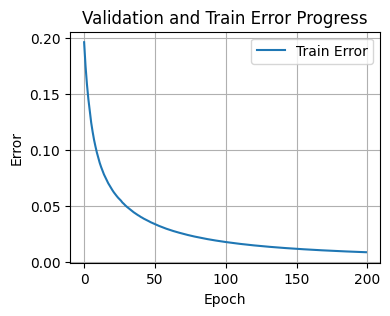

,Input,Predicted,True
0,"[1, 0, 0]","[[0.96, 0.99, 0.16]]","[1, 1, 0]"
1,"[1, 0, 1]","[[0.11, 0.99, 0.94]]","[0, 1, 1]"
2,"[0, 1, 0]","[[0.96, 0.07, 0.16]]","[1, 0, 0]"
3,"[0, 1, 1]","[[0.11, 0.06, 0.94]]","[0, 0, 1]"
4,"[1, 1, 0]","[[1.0, 0.95, 0.83]]","[1, 1, 1]"
5,"[1, 1, 1]","[[0.86, 0.94, 1.0]]","[1, 1, 1]"


In [19]:
# Data and parameters:
inputs, true_outputs = example_gallblader_attack()
data_description = "Logical function"
print(inputs.shape, true_outputs.shape)

# set parameters:
print_progress = True
activation = 'sigmoid'
learning_rate = 0.9 #  0.5
init_method = 'random'
adaptive_learning_rate = False
min_error = 0.0001
epochs = 200
variant = "iterative"
validation_data = None
max_validation_steps = None
error_name = 'SSE' # 'BCE' 'SSE'

# run the experiment:

# Train the linear neuron:
perceptron = PerceptronLayer(inputs.shape[1], true_outputs.shape[1], activation, init_method)


if variant == 'iterative':
    [training_errors, validation_errors] = perceptron.gradient_descent_iterative(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress, error_name)
else:
    [training_errors, validation_errors] = perceptron.gradient_descent_batch(inputs, true_outputs, learning_rate, epochs, adaptive_learning_rate, min_error, max_validation_steps, validation_data, print_progress, error_name)


# Print summary:
print(perceptron)
real_outputs = perceptron.forward(inputs) # forward for the whole dataset
error = perceptron_error(true_outputs, real_outputs)
print(f"Perceptron error: {error}")
print(f"MAE error: {MAE_error(true_outputs, real_outputs)}")
print(f"MSE error: {MSE_error(true_outputs, real_outputs)}")
print
plot_error_progress(training_errors, validation_errors)


# Create a pandas DataFrame for a nice table
import pandas as pd
df = pd.DataFrame(columns=['Input', 'Predicted', 'True'])
for inputs, label in zip(inputs, true_outputs):
    df.loc[len(df)] = {'Input': inputs, 'Predicted': perceptron.forward(inputs).round(2), 'True': label}
df


- observe and try to interpret the final weight matrix
- are the weights as expected? (e.g., the second column)?

In [20]:
perceptron.weights.round(2), perceptron.biases.round(2)


(array([[ 3.88,  5.5 ,  3.22],
        [ 3.88, -1.83,  3.22],
        [-5.15, -0.12,  4.43]]),
 array([[-0.78, -0.79, -4.87]]))

# Example:  Letters
#### Dataset Description:
The dataset consists of 78 black and white images of letters represented as numerical arrays.
Each image is a 50x50 grid where pixel values are either -1 (black) or 1 (white).
- The first column in the dataset contains the class label, which represents the letter index (1-26).
- The remaining columns contain pixel values for the respective image.

In [ ]:
# load the perceptron_library.py file into google colab
import urllib.request

url = 'https://raw.githubusercontent.com/reitezuz/18NES1-2025-/refs/heads/main/week2/perceptron_library.py'
filename = 'perceptron_library.py'
urllib.request.urlretrieve(url, filename)


('perceptron_library.py', <http.client.HTTPMessage at 0x78d28856deb0>)

In [ ]:
# import libraries
#from perceptron_library import *
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
def load_letter_data():
    """ Load letter image data from a CSV file hosted on GitHub into numpy arrays """
    github_url = "https://github.com/reitezuz/18NES1-2025-/blob/cd9bb8168f96cb0c35a6502c0d1b3874113c24ae/week2/letters.csv"
    url = github_url.replace("github.com", "raw.githubusercontent.com").replace("blob/", "")
    df = pd.read_csv(url, header=None)
    labels = df.iloc[:, 0].values   # First column is the class label
    inputs = df.iloc[:, 1:].values  # Remaining columns are features (-1, 1)
    return inputs, labels

def visualize_letter(X, labels, index):
    """ Visualize the i-th row of the data as a 50x50 black and white image """
    image = - X[index].reshape(50, 50)  # Reshape to 50x50
    letter = label_to_letter(labels[index])
    plt.figure(figsize=(2,2))         # Figure size
    plt.imshow(image, cmap='gray', vmin=-1, vmax=1)
    plt.title(f"Letter Image at Index {index} ... {letter}")
    plt.axis('off')
    plt.show()

def label_to_letter(label):
    """ Convert a label (1-26) to a corresponding letter (A-Z) """
    return chr(label + 64)

def add_noise(X, alpha=0.01):
    """ Add salt & pepper noise to the dataset and apply median filtering """
    from scipy.ndimage import median_filter
    X = (X + 1) / 2  # Convert from [-1,1] to [0,1]
    X_noisy = X.copy()
    X_denoised = X.copy()

    for i in range(X.shape[0]):
        img = X[i].reshape(50, 50)

        # Add salt & pepper noise
        noisy_img = img.copy()
        noise = np.random.choice([0, 1, -1], size=img.shape, p=[1 - alpha, alpha / 2, alpha / 2])
        noisy_img[noise == -1] = 0  # Salt (white)
        noisy_img[noise == 1] = 1   # Pepper (black)

        # Apply median filter
        denoised_img = median_filter(noisy_img, size=3)

        # Flatten back to vector form
        X_noisy[i] = noisy_img.flatten()
        X_denoised[i] = denoised_img.flatten()

    X_noisy = X_noisy * 2 - 1  # Convert back to [-1,1]
    X_denoised = X_denoised * 2 - 1  # Convert back to [-1,1]

    return X_noisy, X_denoised

def show_noisy_and_denoised(X_original, X_noisy, X_denoised, index):
    """ Display original, noisy, and denoised images side by side """
    fig, axes = plt.subplots(1, 3, figsize=(10, 5))

    original_img = - X_original[index].reshape(50, 50)
    noisy_img = - X_noisy[index].reshape(50, 50)
    denoised_img = - X_denoised[index].reshape(50, 50)

    axes[0].imshow(original_img, cmap='gray', vmin=-1, vmax=1)
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    axes[1].imshow(noisy_img, cmap='gray', vmin=-1, vmax=1)
    axes[1].set_title("Noisy Image")
    axes[1].axis('off')

    axes[2].imshow(denoised_img, cmap='gray', vmin=-1, vmax=1)
    axes[2].set_title("Denoised Image")
    axes[2].axis('off')

    plt.show()


### Analyze the data:

In [ ]:
# Load the data:
[inputs, labels] = load_letter_data()

print(np.shape(inputs), np.shape(labels))
print(np.max(inputs), np.min(inputs), np.max(labels), np.min(labels))



(78, 2500) (78,)
1 -1 26 1


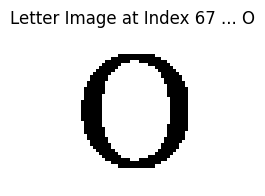

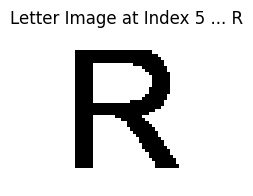

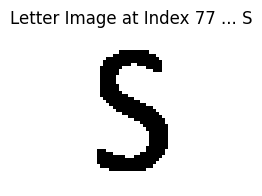

In [ ]:
# Visualize some letters:
indexes = [67, 5, 77]
for index in indexes:
    visualize_letter(inputs, labels, index)


Create the testing set by adding noise and denoising:
- experiment with the level of noise, alpha

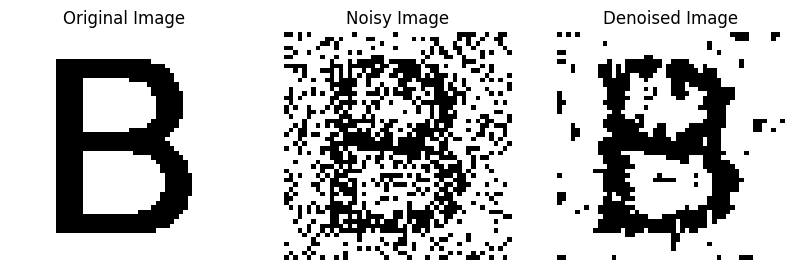

In [ ]:
[inputs_noisy, inputs_denoised] = add_noise(inputs, alpha=0.5)
index = 10
show_noisy_and_denoised(inputs, inputs_noisy, inputs_denoised, index)

## Train the Perceptron layer to recognize letters

In [ ]:
# DataFrame to store the results for comparisons
experiment_results_let = pd.DataFrame(columns=['Epochs', 'MSE', 'Accuracy','Sum Accuracy', 'Test MSE', 'Test Accuracy', 'Test MSE2', 'Test Accuracy2', 'Time', 'Variant', 'Learning Rate', 'Adaptive Learning Rate', 'Activation Function', 'Init Method', 'Max Epochs', 'Data Description'])

### 5 letters

- set the hyperparametrers, run the experiment and observe the results:
- observe the characteristic shape of the error progress (for SSE)

Gradient Descent Iterative:
Epoch: 0, Training error (SSE):0.3622 Average of Weights: -0.0001687843537576964  Learning rate: 0.0010
Epoch: 100, Training error (SSE):0.0055 Average of Weights: 0.0010883952352043155  Learning rate: 0.0010
Epoch: 200, Training error (SSE):0.0017 Average of Weights: 0.0012266227392349685  Learning rate: 0.0010
Epoch: 300, Training error (SSE):0.0011 Average of Weights: 0.0012974250456266989  Learning rate: 0.0010
Epoch: 400, Training error (SSE):0.0008 Average of Weights: 0.0013453834626825415  Learning rate: 0.0010
The training ended after 500 epochs. Maximum epochs reached.


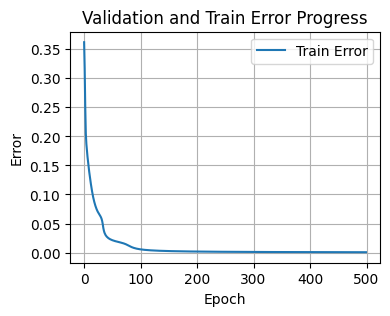


Experiment Results:


,Epochs,MSE,Accuracy,Sum Accuracy,Test MSE,Test Accuracy,Test MSE2,Test Accuracy2,Time,Variant,Learning Rate,Adaptive Learning Rate,Activation Function,Init Method,Max Epochs,Data Description
0,500.0,0.000601,1.0,1,0.063414,0.8,0.063414,0.8,1.55923,iterative,0.001,False,sigmoid,random,500,Letter classification


In [ ]:
alpha = 0.3       # level of noise in the testing data

np.random.seed(47876)
# Preprocess the data:
[inputs, labels] = load_letter_data()

mask = (labels == 1) | (labels == 2) | (labels == 3) | (labels == 4)| (labels == 5)
inputs = inputs[mask]
labels = labels[mask]

[inputs_noisy, inputs_denoised] = add_noise(inputs, alpha=alpha)
true_outputs = one_hot_encode(labels)
training_data = (inputs, true_outputs)


testing_data = (inputs_noisy, true_outputs)
validation_data = None
testing_data2 = (inputs_denoised, true_outputs)
data_description = "Letter classification"

# Set Perceptron parameters:
weights = np.zeros(inputs.shape[1])
bias = 0
activation = 'sigmoid'
init_method = 'random'
epochs = 500
learning_rate = 0.001
adaptive_learning_rate = False
min_error = 0.0001
print_progress = True
variant ='iterative' # 'batch' # 'batch' 'iterative'
max_validation_steps = 30
error_name = 'SSE'

# run the experiment:
#for learning_rate in [0.0001, 0.001, 0.01, 0.1, 1]:

perceptron = run_example_multiple_times_classification(experiment_results_let, training_data, testing_data, testing_data2, validation_data, activation, epochs, init_method, learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, error_name, max_validation_steps, num_runs=1)

#perceptron = run_example_multiple_times_classification(experiment_results_let, training_data, testing_data, testing_data2, validation_data, activation, epochs, init_method, learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, max_validation_steps, num_runs=1)

print("\nExperiment Results:")
experiment_results_let

- visualize misclassified letters:

Misclassified Letters:


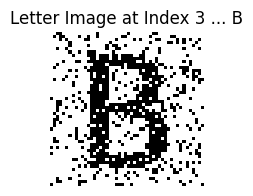

  Predicted: D, Actual: B
  Output: [0.15 0.11 0.01 0.27 0.07]
  Probabilities: [0.21 0.2  0.18 0.23 0.19]


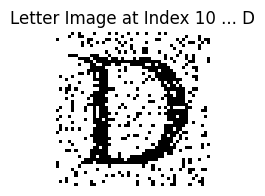

  Predicted: B, Actual: D
  Output: [0.05 0.47 0.02 0.43 0.19]
  Probabilities: [0.17 0.24 0.17 0.23 0.19]


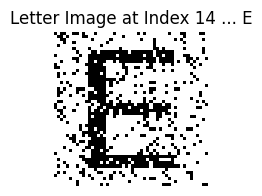

  Predicted: D, Actual: E
  Output: [0.01 0.01 0.01 0.41 0.31]
  Probabilities: [0.18 0.18 0.18 0.25 0.23]


In [ ]:
outputs = perceptron.forward(inputs_noisy)

# Find misclassified letters
misc = misclassified_indices(true_outputs, outputs)
outputs = perceptron.forward(inputs_noisy)

# Visualize misclassified letters
print("Misclassified Letters:")
for index in misc:
    visualize_letter(inputs_noisy, labels, index)
    predicted_class = np.argmax(outputs[index]) + 1  # Get predicted class index (add 1 to adjust for 1-based indexing)
    print(f"  Predicted: {label_to_letter(predicted_class)}, Actual: {label_to_letter(labels[index])}")
    print(f"  Output: {np.round(outputs[index], 2)}")
    print(f"  Probabilities: {np.round((outputs[index]+1)/np.sum(outputs[index]+1),2)}")

- train with softmax and categorical cross-entropy

Gradient Descent Iterative:
Epoch: 0, Training error (CCE):1.9103 Average of Weights: -0.0005057735765197314  Learning rate: 0.0010
Epoch: 100, Training error (CCE):0.0083 Average of Weights: -0.0005057735765197547  Learning rate: 0.0010
The training ended after 200 epochs. Maximum epochs reached.


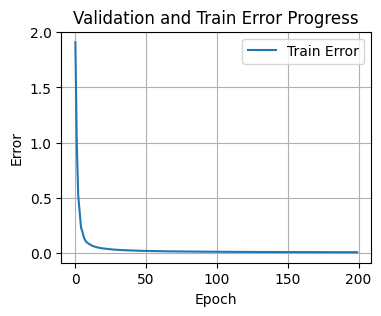


Experiment Results:


,Epochs,MSE,Accuracy,Sum Accuracy,Test MSE,Test Accuracy,Test MSE2,Test Accuracy2,Time,Variant,Learning Rate,Adaptive Learning Rate,Activation Function,Init Method,Max Epochs,Data Description
0,500.0,0.000601,1.0,1,0.063414,0.8,0.063414,0.8,1.559230,iterative,0.001,False,sigmoid,random,500,Letter classification
1,200.0,0.000003,1.0,1,0.022207,0.8,0.022207,0.8,3.546265,iterative,0.001,False,softmax,random,200,Letter classification


In [ ]:
alpha = 0.3      # level of noise in the testing data

#np.random.seed(47876)
# Preprocess the data:
[inputs, labels] = load_letter_data()

mask = (labels == 1) | (labels == 2) | (labels == 3) | (labels == 4)| (labels == 5) | (labels == 6) | (labels == 7) | (labels == 8) | (labels == 9)| (labels == 10)
inputs = inputs[mask]
labels = labels[mask]

[inputs_noisy, inputs_denoised] = add_noise(inputs, alpha=alpha)
true_outputs = one_hot_encode(labels)
training_data = (inputs, true_outputs)


testing_data = (inputs_noisy, true_outputs)
validation_data = None
testing_data2 = (inputs_denoised, true_outputs)
data_description = "Letter classification"

# Set Perceptron parameters:
weights = np.zeros(inputs.shape[1])
bias = 0
activation = 'softmax'
init_method = 'random'
epochs = 200
learning_rate = 0.001
adaptive_learning_rate = False
min_error = 0.0001
print_progress = True
variant ='iterative' # 'batch' # 'batch' 'iterative'
max_validation_steps = 30
error_name = 'CCE'

# run the experiment:
#for learning_rate in [0.0001, 0.001, 0.01, 0.1, 1]:

perceptron = run_example_multiple_times_classification(experiment_results_let, training_data, testing_data, testing_data2, validation_data, activation, epochs, init_method, learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, error_name, max_validation_steps, num_runs=1)

print("\nExperiment Results:")
experiment_results_let

Misclassified Letters:


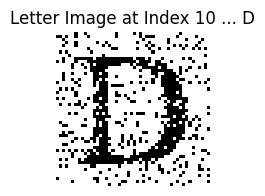

  Predicted: B, Actual: D
  Output: [0.01 0.5  0.02 0.13 0.01 0.   0.25 0.08 0.   0.  ]
  Probabilities: [0.09 0.14 0.09 0.1  0.09 0.09 0.11 0.1  0.09 0.09]


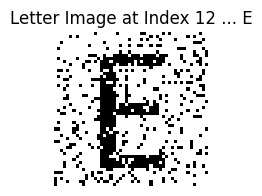

  Predicted: B, Actual: E
  Output: [0.   0.61 0.09 0.   0.11 0.07 0.   0.   0.1  0.01]
  Probabilities: [0.09 0.15 0.1  0.09 0.1  0.1  0.09 0.09 0.1  0.09]


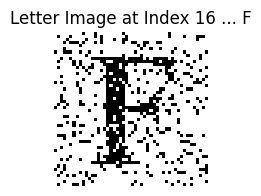

  Predicted: E, Actual: F
  Output: [0.01 0.19 0.06 0.   0.47 0.25 0.   0.   0.   0.02]
  Probabilities: [0.09 0.11 0.1  0.09 0.13 0.11 0.09 0.09 0.09 0.09]


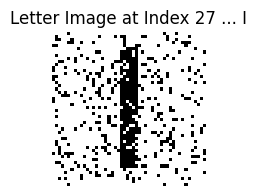

  Predicted: B, Actual: I
  Output: [0.   0.44 0.   0.01 0.01 0.01 0.   0.   0.27 0.26]
  Probabilities: [0.09 0.13 0.09 0.09 0.09 0.09 0.09 0.09 0.12 0.11]


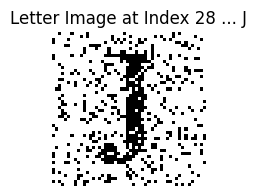

  Predicted: I, Actual: J
  Output: [0.2  0.   0.   0.02 0.   0.03 0.   0.   0.56 0.18]
  Probabilities: [0.11 0.09 0.09 0.09 0.09 0.09 0.09 0.09 0.14 0.11]


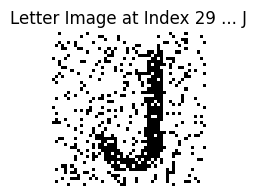

  Predicted: I, Actual: J
  Output: [0.   0.   0.   0.   0.   0.02 0.   0.   0.56 0.41]
  Probabilities: [0.09 0.09 0.09 0.09 0.09 0.09 0.09 0.09 0.14 0.13]


In [ ]:
outputs = perceptron.forward(inputs_noisy)

# Find misclassified letters
misc = misclassified_indices(true_outputs, outputs)
outputs = perceptron.forward(inputs_noisy)

# Visualize misclassified letters
print("Misclassified Letters:")
for index in misc:
    visualize_letter(inputs_noisy, labels, index)
    predicted_class = np.argmax(outputs[index]) + 1  # Get predicted class index (add 1 to adjust for 1-based indexing)
    print(f"  Predicted: {label_to_letter(predicted_class)}, Actual: {label_to_letter(labels[index])}")
    print(f"  Output: {np.round(outputs[index], 2)}")
    print(f"  Probabilities: {np.round((outputs[index]+1)/np.sum(outputs[index]+1),2)}")

In [ ]:
Y = perceptron.forward(inputs_noisy)
D = true_outputs

err = np.abs(D - Y)
print(misclassified_indices(true_outputs, Y), accuracy(D, Y))
print( np.sum(D >0.98, axis=0), np.sum(D <-0.98, axis=0))
print( np.sum(Y >0.098, axis=0), np.sum(Y <-0.098, axis=0))

[10 12 16 27 28 29] 0.8
[3 3 3 3 3 3 3 3 3 3] [0 0 0 0 0 0 0 0 0 0]
[4 8 3 5 5 3 5 5 7 4] [0 0 0 0 0 0 0 0 0 0]


### All letters

Gradient Descent Iterative:
Epoch: 0, Training error (CCE):2.8266 Average of Weights: 0.0002513195532321438  Learning rate: 0.0010
Epoch: 100, Training error (CCE):0.0097 Average of Weights: 0.00025131955323214424  Learning rate: 0.0010
The training ended after 200 epochs. Maximum epochs reached.


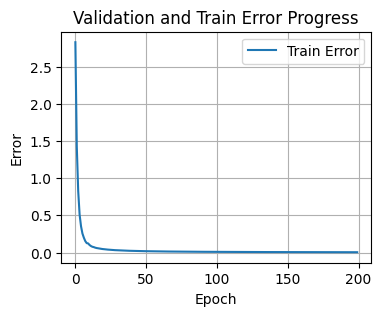


Experiment Results:


,Epochs,MSE,Accuracy,Sum Accuracy,Test MSE,Test Accuracy,Test MSE2,Test Accuracy2,Time,Variant,Learning Rate,Adaptive Learning Rate,Activation Function,Init Method,Max Epochs,Data Description
0,500.0,0.000601,1.0,1,0.063414,0.800000,0.063414,0.800000,1.559230,iterative,0.001,False,sigmoid,random,500,Letter classification
1,200.0,0.000003,1.0,1,0.022207,0.800000,0.022207,0.800000,3.546265,iterative,0.001,False,softmax,random,200,Letter classification
2,200.0,0.000002,1.0,1,0.008810,0.871795,0.008810,0.871795,9.462551,iterative,0.001,False,softmax,random,200,Letter classification


In [ ]:
alpha = 0.3      # level of noise in the testing data

#np.random.seed(47876)
# Preprocess the data:
[inputs, labels] = load_letter_data()


[inputs_noisy, inputs_denoised] = add_noise(inputs, alpha=alpha)
true_outputs = one_hot_encode(labels)
training_data = (inputs, true_outputs)


testing_data = (inputs_noisy, true_outputs)
validation_data = None
testing_data2 = (inputs_denoised, true_outputs)
data_description = "Letter classification"

# Set Perceptron parameters:
weights = np.zeros(inputs.shape[1])
bias = 0
activation = 'softmax'
init_method = 'random'
epochs = 200
learning_rate = 0.001
adaptive_learning_rate = False
min_error = 0.0001
print_progress = True
variant ='iterative' # 'batch' # 'batch' 'iterative'
max_validation_steps = 30
error_name = 'CCE'

# run the experiment:
#for learning_rate in [0.0001, 0.001, 0.01, 0.1, 1]:

perceptron = run_example_multiple_times_classification(experiment_results_let, training_data, testing_data, testing_data2, validation_data, activation, epochs, init_method, learning_rate, print_progress, variant, data_description, adaptive_learning_rate, min_error, error_name, max_validation_steps, num_runs=1)

print("\nExperiment Results:")
experiment_results_let

Misclassified Letters:


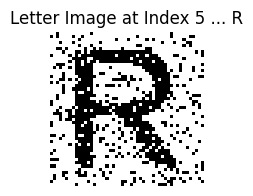

  Predicted: P, Actual: R
  Output: [0.   0.18 0.01 0.   0.09 0.   0.07 0.07 0.   0.   0.08 0.   0.   0.
 0.   0.34 0.01 0.15 0.   0.   0.   0.   0.   0.   0.   0.  ]
  Probabilities: [0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.05 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04]


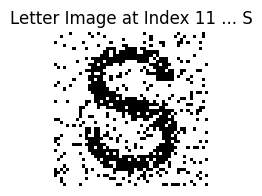

  Predicted: B, Actual: S
  Output: [0.   0.49 0.   0.   0.   0.   0.01 0.   0.   0.02 0.01 0.   0.   0.01
 0.05 0.01 0.   0.01 0.32 0.   0.04 0.01 0.   0.   0.   0.  ]
  Probabilities: [0.04 0.06 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.05 0.04 0.04 0.04 0.04 0.04 0.04 0.04]


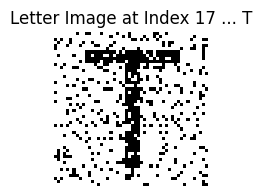

  Predicted: Z, Actual: T
  Output: [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.06 0.   0.08 0.   0.   0.   0.84]
  Probabilities: [0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.07]


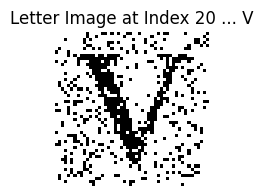

  Predicted: F, Actual: V
  Output: [0.   0.   0.   0.   0.   0.91 0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.07 0.   0.   0.01 0.  ]
  Probabilities: [0.04 0.04 0.04 0.04 0.04 0.07 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04]


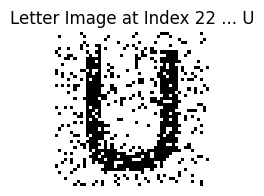

  Predicted: G, Actual: U
  Output: [0.   0.   0.02 0.03 0.   0.   0.87 0.   0.   0.   0.   0.   0.   0.01
 0.   0.   0.   0.   0.   0.   0.06 0.   0.   0.   0.   0.  ]
  Probabilities: [0.04 0.04 0.04 0.04 0.04 0.04 0.07 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04]


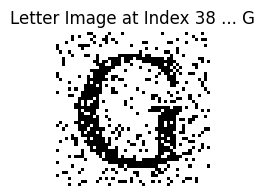

  Predicted: S, Actual: G
  Output: [0.   0.   0.05 0.   0.01 0.01 0.13 0.   0.02 0.01 0.   0.02 0.02 0.
 0.03 0.   0.   0.14 0.44 0.   0.12 0.   0.   0.   0.   0.  ]
  Probabilities: [0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.05 0.04 0.04 0.04 0.04 0.04 0.04 0.04]


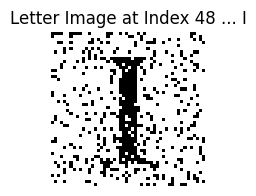

  Predicted: T, Actual: I
  Output: [0.   0.   0.1  0.   0.   0.   0.   0.   0.3  0.01 0.   0.07 0.02 0.
 0.   0.   0.   0.   0.01 0.34 0.04 0.01 0.   0.   0.05 0.03]
  Probabilities: [0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.05 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.05 0.04 0.04 0.04 0.04 0.04 0.04]


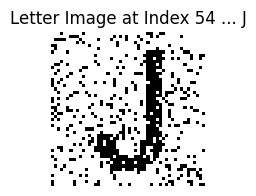

  Predicted: L, Actual: J
  Output: [0.   0.   0.   0.   0.   0.   0.   0.   0.04 0.   0.   0.58 0.   0.01
 0.   0.   0.01 0.   0.   0.   0.32 0.01 0.01 0.   0.   0.02]
  Probabilities: [0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.06 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.05 0.04 0.04 0.04 0.04 0.04]


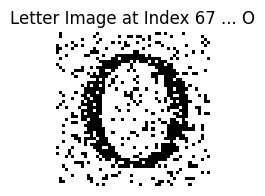

  Predicted: S, Actual: O
  Output: [0.   0.   0.   0.01 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.08 0.01 0.   0.   0.89 0.   0.   0.   0.01 0.   0.   0.  ]
  Probabilities: [0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.07 0.04 0.04 0.04 0.04 0.04 0.04 0.04]


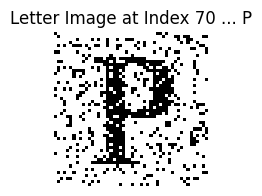

  Predicted: F, Actual: P
  Output: [0.06 0.04 0.   0.15 0.01 0.22 0.01 0.13 0.02 0.09 0.   0.02 0.01 0.
 0.   0.03 0.   0.   0.03 0.01 0.01 0.02 0.   0.12 0.02 0.01]
  Probabilities: [0.04 0.04 0.04 0.04 0.04 0.05 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04]


In [ ]:
outputs = perceptron.forward(inputs_noisy)

# Find misclassified letters
misc = misclassified_indices(true_outputs, outputs)
outputs = perceptron.forward(inputs_noisy)

# Visualize misclassified letters
print("Misclassified Letters:")
for index in misc:
    visualize_letter(inputs_noisy, labels, index)
    predicted_class = np.argmax(outputs[index]) + 1  # Get predicted class index (add 1 to adjust for 1-based indexing)
    print(f"  Predicted: {label_to_letter(predicted_class)}, Actual: {label_to_letter(labels[index])}")
    print(f"  Output: {np.round(outputs[index], 2)}")
    print(f"  Probabilities: {np.round((outputs[index]+1)/np.sum(outputs[index]+1),2)}")